In [1]:
%cd ../..

/home/jj/Research/ConceptualSensitivityRegularization


# Source dataset: oxford-iiit-pet

In [ ]:
import os


img_list = ['_'.join(i.split('_')[:-1]) for i in os.listdir('/media/disk1/Data/oxford-iiit-pet/images') if i.endswith('.jpg')]
sets = set(img_list)

print('total number of dataset:', len(img_list))

print()
print('--num dataset != 200')

for name in sets:
    if img_list.count(name) != 200:
        print(name, len([i for i in img_list if i == name]))



# SpurioudCatDog dataset generation

In [ ]:
from csr.module.dataset.prepare_dataset import PrepareDataset

prep = PrepareDataset(
    places365_root='/media/disk2/Data',
    save_root='/media/disk1/Data',
    oxford_iiit_pet_root='/media/disk1/Data',
    dataset="SpuriousCatDog", 
    download=False)

# Checking dataset

In [2]:
from csr.module.dataset.data_module import DataModule
dm = DataModule('catdog', '/media/disk1/Data', 1234, 2, 20, 20, None, None, None, None)

/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
tr = dm.train_dataset
val = dm.val_dataset
te = dm.test_dataset

In [7]:
tr.verbose()
val.verbose()
te.verbose()

{(0, 0): 1465, (0, 1): 166, (1, 0): 71, (1, 1): 3027}
{(0, 0): 190, (0, 1): 388, (1, 0): 194, (1, 1): 411}
{(0, 0): 480, (0, 1): 998, (1, 0): 480, (1, 1): 998}


In [8]:
metadata_path = '/media/disk1/Data/SpuriousCatDog/metadata_catdog.csv'

# to dataframe
import pandas as pd
df = pd.read_csv(metadata_path)


In [14]:
df.groupby(['split','y', 'a']).count()

filename
split y a          
0     0 0      1465
        1        71
      1 0       166
        1      3027
1     0 0       190
        1       194
      1 0       388
        1       411
2     0 0       480
        1       480
      1 0       998
        1       998

In [15]:
df.head()

,filename,split,y,a
0,Abyssinian_1_l_lake_natural_00004157.jpg,0,0,0
1,Abyssinian_10_l_lake_natural_00000954.jpg,0,0,0
2,Abyssinian_100_o_ocean_00002301.jpg,0,0,0
3,Abyssinian_101_l_lake_natural_00004484.jpg,0,0,0
4,Abyssinian_102_o_ocean_00004819.jpg,0,0,0


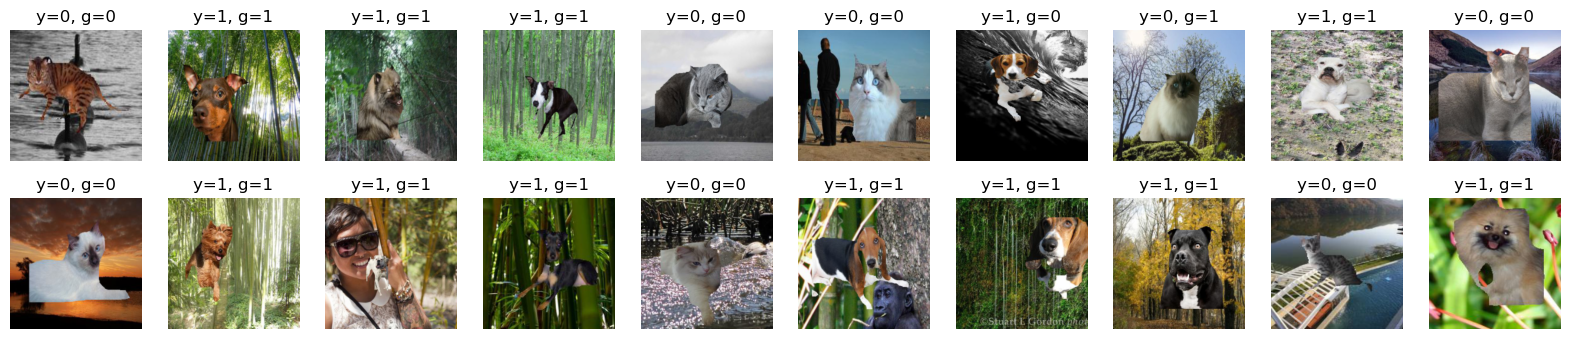

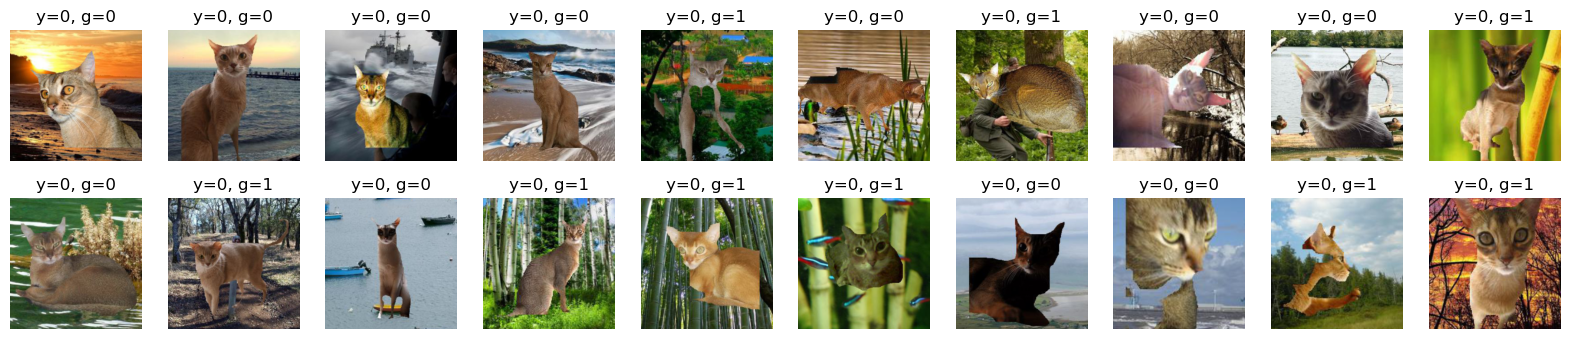

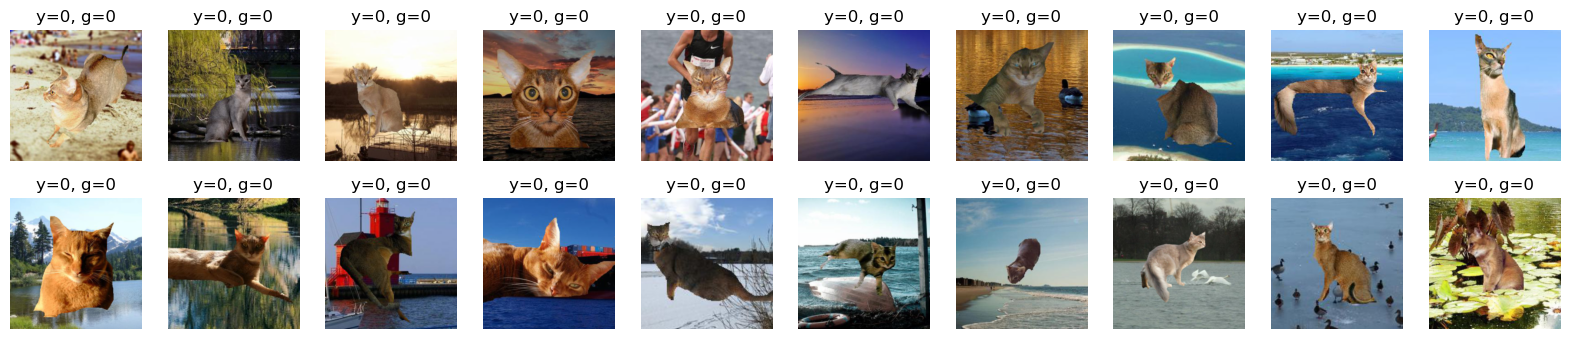

In [22]:
dm.prepare_data()
tr_loader = dm.train_dataloader()
val_loader = dm.val_dataloader()
test_loader = dm.test_dataloader()

# plot some images from each dataloader

import matplotlib.pyplot as plt
import numpy as np

def imshow(img, ax):
    #imagenet mean and std
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std[:, None, None] + mean[:, None, None]
    if img.min() < 0:
        img = img - img.min()
    if img.max() > 1:
        img = img / img.max()
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))


for x, y, g, _ in tr_loader:
    fig, ax = plt.subplots(2, 10, figsize=(20, 4))
    for i in range(10):
        for j in range(2):
            imshow(x[i*2+j], ax[j][i])
            ax[j][i].set_title(f'y={y[i*2+j].item()}, g={g[i*2+j].item()}')
            ax[j][i].axis('off')

    plt.show()

    break

for x, y, g, _ in val_loader[0]:
    fig, ax = plt.subplots(2, 10, figsize=(20, 4))
    for i in range(10):
        for j in range(2):
            imshow(x[i*2+j], ax[j][i])
            ax[j][i].set_title(f'y={y[i*2+j].item()}, g={g[i*2+j].item()}')
            ax[j][i].axis('off')

    plt.show()

    break

for x, y, g, _ in test_loader:
    fig, ax = plt.subplots(2, 10, figsize=(20, 4))
    for i in range(10):
        for j in range(2):
            imshow(x[i*2+j], ax[j][i])
            ax[j][i].set_title(f'y={y[i*2+j].item()}, g={g[i*2+j].item()}')
            ax[j][i].axis('off')

    plt.show()

    break